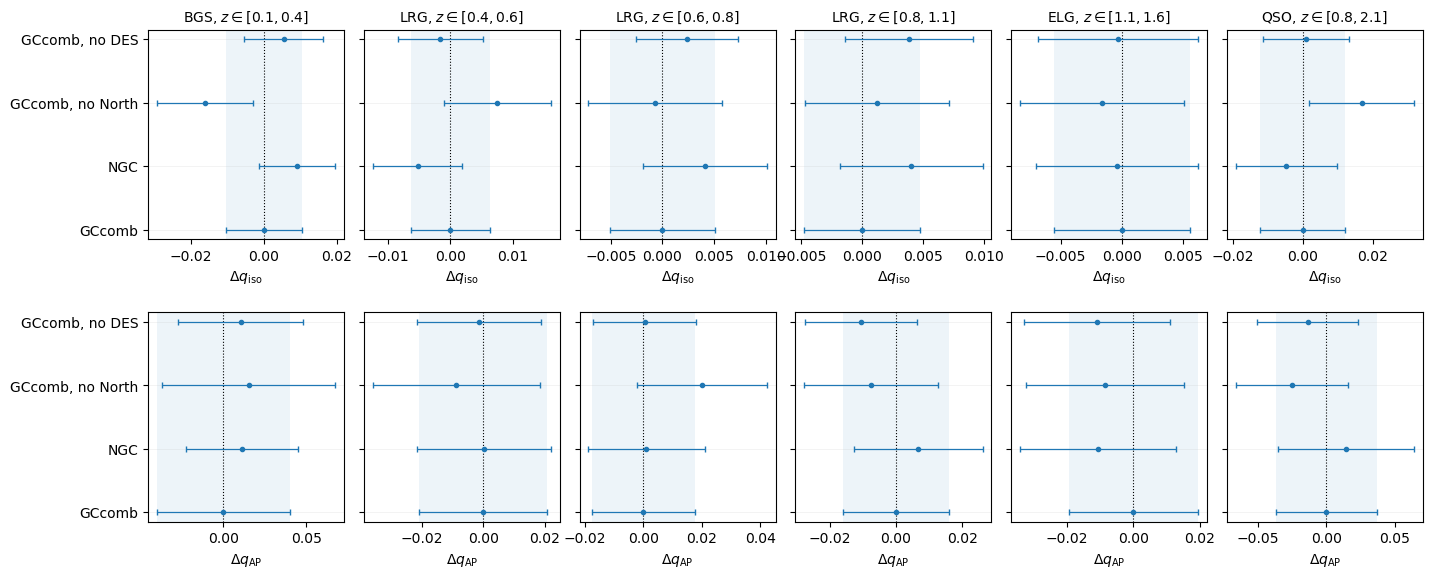

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from desilike.samples import MCSamples

plot_dir = Path('dr3_bao')
plot_dir.mkdir(exist_ok=True)
ext = 'png'


def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples


fits_dir = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao/with_desi-clustering/data-dr3-matterhorn-v2-v0-bao')

tracers = {
    'BGS1': ('z0p1-0p4', r'BGS, $z \in [0.1, 0.4]$'),
    'LRG1': ('z0p4-0p6', r'LRG, $z \in [0.4, 0.6]$'),
    'LRG2': ('z0p6-0p8', r'LRG, $z \in [0.6, 0.8]$'),
    'LRG3': ('z0p8-1p1', r'LRG, $z \in [0.8, 1.1]$'),
    'ELG2': ('z1p1-1p6', r'ELG, $z \in [1.1, 1.6]$'),
    'QSO1': ('z0p8-2p1', r'QSO, $z \in [0.8, 2.1]$'),
}

regions = {
    'GCcomb': 'GCcomb',
    'NGC': 'NGC',
    'GCcomb_noN': 'GCcomb, no North',
    'GCcomb_noDES': 'GCcomb, no DES',
}

params = {'qiso': r'\Delta q_{\rm iso}', 'qap': r'\Delta q_{\rm AP}'}

samples = {}
for tracer, (zrange, title) in tracers.items():
    for region in regions:
        directories = list(fits_dir.glob(f'template-bao_{tracer}-{zrange}-{region}-C2R-*'))
        if len(directories) != 1:
            raise ValueError(f'Found {len(directories)} directories for {tracer}, {region}: {directories}')
        samples[tracer, region] = read_samples([directories[0] / f'samples_{ichain:d}.h5' for ichain in range(1, 5)], burnin=0.5, thin=10)


fig, axes = plt.subplots(len(params), len(tracers), figsize=(2.5 * len(tracers), 6.), sharey=True, squeeze=False)
y = np.arange(len(regions))

for icol, (tracer, (zrange, title)) in enumerate(tracers.items()):
    for irow, (param, xlabel) in enumerate(params.items()):
        ax = axes[irow, icol]

        baseline = samples[tracer, 'GCcomb']
        baseline_mean, baseline_std = baseline.mean(param), baseline.std(param)

        means = np.array([samples[tracer, region].mean(param) for region in regions])
        stds = np.array([samples[tracer, region].std(param) for region in regions])

        ax.axvspan(-baseline_std, baseline_std, alpha=0.08)
        ax.axvline(0., color='k', linestyle=':', linewidth=0.8)
        ax.errorbar(means - baseline_mean, y, xerr=stds, fmt='o', markersize=3., linewidth=0.9, capsize=2.)

        ax.set_xlabel(f'${xlabel}$')
        ax.grid(axis='y', linewidth=0.4, alpha=0.25)
        ax.invert_yaxis()

        if irow == 0:
            ax.set_title(title, fontsize=10)

        if icol == 0:
            ax.set_yticks(y, labels=regions.values())
        else:
            ax.tick_params(axis='y', labelleft=False)

fig.subplots_adjust(left=0.14, right=0.99, bottom=0.10, top=0.92, wspace=0.10, hspace=0.35)
fig.savefig(plot_dir / f'data_splits.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()